In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import RFECV
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

# Set Chinese font and style
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
plt.rcParams['axes.edgecolor'] = 'black'   # Spine color
plt.rcParams['axes.linewidth'] = 1.0       # Spine width
plt.rcParams['axes.grid'] = False        # Master switch

In [56]:
# 1. Load data
df = pd.read_csv('csv/df_k.csv')

# 2. Only take data with k < 20
df_filtered = df[df['k(W/mK)'] < 10].copy()
print(f"Original data count: {len(df)}")
print(f"Filtered data count (k < 10): {len(df_filtered)}")

# 3. Prepare data
X = df_filtered.drop(columns=['k(W/mK)', 'formula', 'composition'])
y = df_filtered['k(W/mK)']

print(f"Feature count: {X.shape[1]}")
print(f"Target variable range: [{y.min():.2f}, {y.max():.2f}]")
print(f"Target variable mean: {y.mean():.2f}")

# 4. Missing value handling
print(f'Feature missing values count: {X.isnull().sum().sum()}')
print(f'Target variable missing values count: {y.isnull().sum()}')

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())
if y.isnull().sum() > 0:
    y = y.fillna(y.mean())

# 5. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set size: {X_train.shape}')
print(f'Testing set size: {X_test.shape}')

# 6. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Original data count: 1003
Filtered data count (k < 10): 970
Feature count: 133
Target variable range: [0.20, 9.93]
Target variable mean: 3.02
Feature missing values count: 0
Target variable missing values count: 0
Training set size: (776, 133)
Testing set size: (194, 133)


In [57]:
# 7. Create XGBoost regression model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# 8. Train model
xgb_model.fit(X_train_scaled, y_train)

# 9. Predict
y_train_pred = xgb_model.predict(X_train_scaled)
y_test_pred  = xgb_model.predict(X_test_scaled)

# 10. Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test, y_test_pred)
mae        = mean_absolute_error(y_test, y_test_pred)

print(f'Training set RMSE: {train_rmse:.3f}')
print(f'Testing set RMSE: {test_rmse:.3f}')
print(f'Training set R²: {train_r2:.3f}')
print(f'Testing set R²: {test_r2:.3f}')
print(f'Testing set MAE: {mae:.3f}')

Training set RMSE: 0.381
Testing set RMSE: 0.725
Training set R²: 0.971
Testing set R²: 0.897
Testing set MAE: 0.483


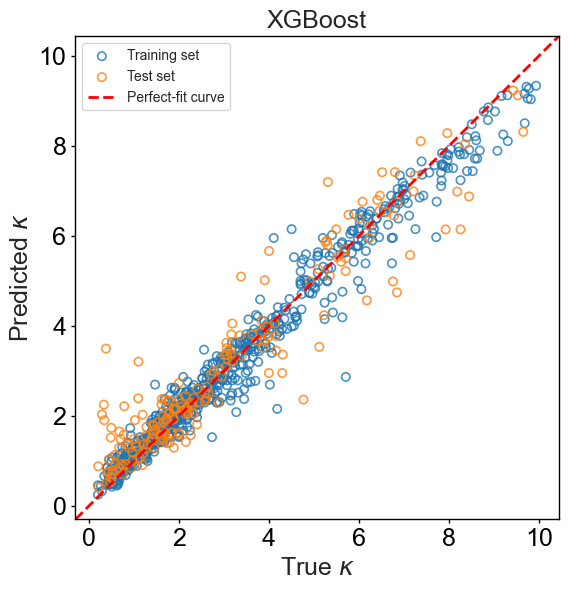

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ax.tick_params(axis='both',          # Operate on both x and y axes
               which='major',        # Major ticks (minor ticks similarly)
               direction='out',       # Ticks inward, out/both also possible
               length=3,             # Tick length
               width=1.0,            # Tick width
               colors='black')       # Tick color

# 1. Training set: hollow blue circles
ax.scatter(y_train, y_train_pred,
           facecolors='none',          # Hollow
           edgecolors='tab:blue',
           linewidth=1.2,
           alpha=0.8,
           label='Training set')

# 2. Test set: hollow orange circles
ax.scatter(y_test, y_test_pred,
           facecolors='none',
           edgecolors='tab:orange',
           linewidth=1.2,
           alpha=0.8,
           label='Test set')

# 3. Perfect fit line
lim = [y.min() - 0.5, y.max() + 0.5]
ax.plot(lim, lim, 'r--', lw=2, label='Perfect-fit curve')

# 4. Other styling
ax.set_xlabel(r'True $\kappa$', fontsize=18)
ax.set_ylabel(r'Predicted $\kappa$', fontsize=18)
ax.set_title('XGBoost', fontsize=18)  # Only change title here
ax.legend()

# # 5. Metric text (upper right corner)
# text_str = (f'Train RMSE = {train_rmse:.3f}\n'
#             f'Train R² = {train_r2:.3f}\n'
#             f'Test RMSE = {test_rmse:.3f}\n'
#             f'Test R² = {test_r2:.3f}')
# ax.text(0.05, 0.95, text_str, transform=ax.transAxes,
#         fontsize=11, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 6. Equal aspect ratio axes
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal', adjustable='box')

# 7. Show tick marks
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=18)

plt.tight_layout()
plt.show()

In [59]:
from sklearn.model_selection import cross_val_score

# 1. Get feature importance and sort
feat_imp = xgb_model.feature_importances_
cols = X.columns
imp_df = pd.DataFrame({'feature': cols, 'importance': feat_imp})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

# 2. Gradually increase features, record CV R²
n_feat = len(imp_df)
r2_mean, r2_std = [], []

base_model = xgb.XGBRegressor(
    n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1
)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

selector = RFECV(
    estimator=base_model, step=1, cv=cv, scoring='r2', min_features_to_select=1, n_jobs=-1
)
selector.fit(X_train_scaled, y_train)

optimal_n = selector.n_features_
selected_mask = selector.support_
selected_cols_raw = X.columns[selected_mask]

X_train_optimal = X_train_scaled[:, selected_mask]
X_test_optimal  = X_test_scaled[:, selected_mask]

final_model = xgb.XGBRegressor(
    n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1
)
final_model.fit(X_train_optimal, y_train)

y_train_pred = final_model.predict(X_train_optimal)
y_test_pred  = final_model.predict(X_test_optimal)

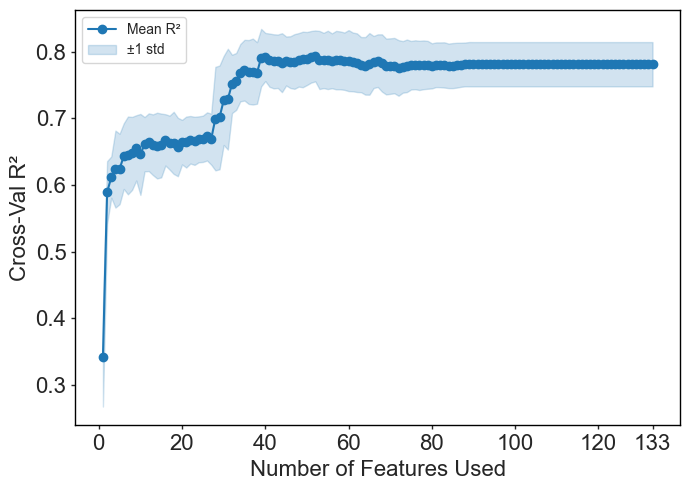

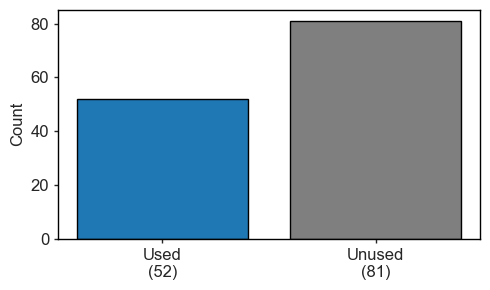

In [60]:
r2_mean = selector.cv_results_['mean_test_score']
r2_std = selector.cv_results_['std_test_score']
n_feat_total = len(r2_mean)

# -- 图3：CV R² 折线图 --
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.tick_params(which='both', direction='out', top=False, right=False, left=True, bottom=True, length=3, width=1, labelsize=16)
x_axis = np.arange(1, n_feat_total + 1)
ax1.plot(x_axis, r2_mean, 'o-', color='tab:blue', label='Mean R²')
ax1.fill_between(x_axis, np.array(r2_mean) - np.array(r2_std), np.array(r2_mean) + np.array(r2_std), color='tab:blue', alpha=0.2, label='±1 std')
ax1.set_xlabel('Number of Features Used', fontsize=16)
ax1.set_ylabel('Cross-Val R²', fontsize=16)
ticks = [0, 20, 40, 60, 80, 100, 120, n_feat_total]
ax1.set_xticks([t for t in ticks if t <= n_feat_total])
ax1.legend()
plt.tight_layout()
plt.show()


n_zero = n_feat_total - optimal_n
fig2, ax2 = plt.subplots(figsize=(5, 3))
ax2.tick_params(which='both', direction='out', top=False, right=False, left=True, bottom=True, length=3, width=1, labelsize=12)
labels = [f'Used\n({optimal_n})', f'Unused\n({n_zero})']
bars = ax2.bar(labels, [optimal_n, n_zero], color=['tab:blue', 'tab:gray'], edgecolor='black')
ax2.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
def short_name(s):
    # 1. Remove MagpieData prefix and spaces
    s = re.sub(r'^MagpieData\s+', '', s)

    # 2. Split string to get statistic type and property name
    parts = s.split()
    if len(parts) >= 2:
        stat_type = parts[0]  # Statistic type: maximum, minimum, mean, avg_dev, etc.
        prop_name = ' '.join(parts[1:])  # Property name

        # 3. Convert statistic type to abbreviation
        if stat_type == 'maximum':
            stat_abbr = 'max'
        elif stat_type == 'minimum':
            stat_abbr = 'min'
        elif stat_type == 'avg_dev':
            stat_abbr = 'avg_dev'  # Keep unchanged
        elif stat_type == 'mean':
            stat_abbr = 'mean'  # Keep unchanged
        else:
            stat_abbr = stat_type  # Keep other types unchanged

        # 4. Process property name: take first two letters + last letter
        # Remove spaces and underscores from property name
        clean_prop = prop_name.replace(' ', '').replace('_', '')

        if len(clean_prop) >= 3:
            # Take first two letters + last letter
            prop_abbr = clean_prop[:2] + clean_prop[-1]
        else:
            # If property name is too short, use as is
            prop_abbr = clean_prop

        # 5. Combine result: statistic abbreviation_property abbreviation
        return f"{stat_abbr}_{prop_abbr}"
    else:
        # If no space separation, process directly
        if len(s) > 10:
            return s[:10] + '…'
        return s

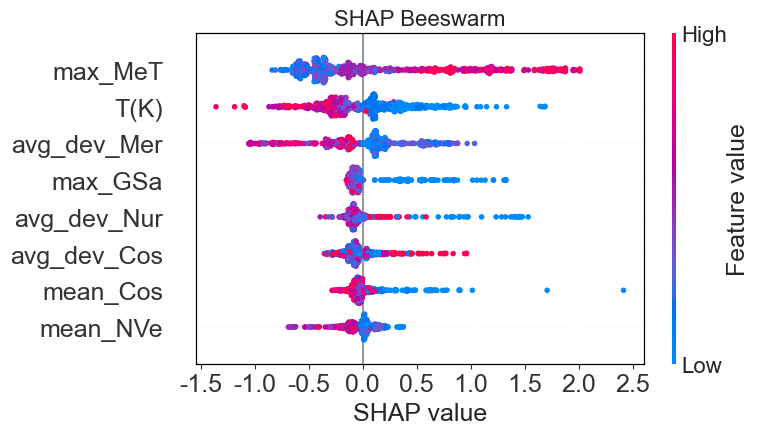

In [62]:

selected_cols_short = [short_name(c) for c in selected_cols_raw]


X_optimal_df = pd.DataFrame(X_train_optimal, columns=selected_cols_short)


explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_optimal_df)

display_n = 8

plt.figure(facecolor='white')
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
})

shap.summary_plot(shap_values, X_optimal_df, show=False, max_display=display_n)
ax3 = plt.gca()
ax3.grid(False)

fig3 = plt.gcf()
cb_ax = fig3.axes[-1]
cb_ax.set_ylabel('Feature value', fontsize=18)
cb_ax.tick_params(labelsize=16)

ax3.set_xlabel('SHAP value', fontsize=18)

for label in ax3.get_yticklabels():
    label.set_fontsize(18)
for label in ax3.get_xticklabels():
    label.set_fontsize(18)
for spine in ax3.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_color('black')

plt.title('SHAP Beeswarm')
plt.tight_layout()
plt.show()

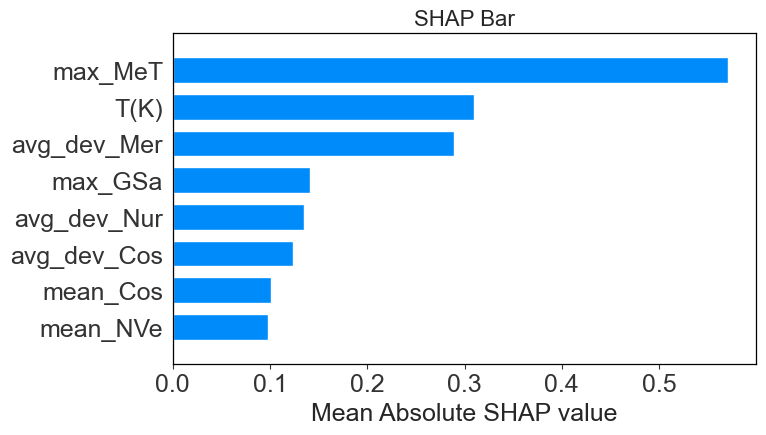

In [63]:

plt.figure(facecolor='white')
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
})

shap.summary_plot(shap_values, X_optimal_df, plot_type="bar", show=False, max_display=display_n)
ax4 = plt.gca()
ax4.grid(False)

ax4.set_xlabel('Mean Absolute SHAP value', fontsize=18)

for label in ax4.get_yticklabels():
    label.set_fontsize(18)
for label in ax4.get_xticklabels():
    label.set_fontsize(18)
for spine in ax4.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_color('black')

plt.title('SHAP Bar')
plt.tight_layout()
plt.show()

In [64]:
shap_df_full = pd.DataFrame(shap_values, columns=X_optimal_df.columns)

mean_abs_shap = shap_df_full.abs().mean().sort_values(ascending=False)
top8_features = mean_abs_shap.head(8).index.tolist()

X8_df = X_optimal_df[top8_features]
shap8_df = shap_df_full[top8_features]


def optimized_negative_zone_quantile(feat_col, shap_col, quantile_range=(0.25, 0.75)):
    """

    """
    tmp = pd.DataFrame({'x': feat_col, 'shap': shap_col})
    neg_samples = tmp.loc[tmp.shap < 0]

    if neg_samples.empty:
        return None, None


    neg_samples_sorted = neg_samples.sort_values('shap')


    n_samples = len(neg_samples_sorted)
    lower_idx = int(quantile_range[0] * n_samples)
    upper_idx = int(quantile_range[1] * n_samples)


    middle_samples = neg_samples_sorted.iloc[lower_idx:upper_idx]


    best_idx = neg_samples['shap'].idxmin()
    best_val = neg_samples.loc[best_idx, 'x']

    left = middle_samples['x'].min()
    right = middle_samples['x'].max()

    return pd.Interval(left, right, closed='both'), best_val

results = {}
for fn in top8_features:
    interval, best_val = optimized_negative_zone_quantile(
        X8_df[fn], shap8_df[fn], quantile_range=(0.25, 0.75)
    )
    results[fn] = {'interval': interval, 'best_val': best_val}



n_iterations = 1000
bootstrap_results = {}

for fn in top8_features:
    best_vals_boot = []


    tmp = pd.DataFrame({'x': X8_df[fn], 'shap': shap8_df[fn]})

    for i in range(n_iterations):

        boot_sample = tmp.sample(n=len(tmp), replace=True, random_state=i)  # 添加random_state确保可重复性


        neg_boot_sample = boot_sample[boot_sample['shap'] < 0]

        if not neg_boot_sample.empty:

            best_idx = neg_boot_sample['shap'].idxmin()
            best_val = neg_boot_sample.loc[best_idx, 'x']


            if hasattr(best_val, 'iloc'):
                best_val = best_val.iloc[0]
            elif hasattr(best_val, 'values'):
                best_val = best_val.item() if best_val.size == 1 else best_val[0]

            best_vals_boot.append(best_val)


    if best_vals_boot:

        best_vals_boot = np.array(best_vals_boot, dtype=float)

        lower_bound = np.percentile(best_vals_boot, 2.5)
        upper_bound = np.percentile(best_vals_boot, 97.5)
        mean_best = np.mean(best_vals_boot)
        std_best = np.std(best_vals_boot)

        bootstrap_results[fn] = {
            'mean_best_val': mean_best,
            'std_best_val': std_best,
            '95% CI Lower': lower_bound,
            '95% CI Upper': upper_bound
        }


print("\n" + "="*80)
print("Bootstrap 95% Confidence Intervals for Optimal Values")
print("="*80)
for fn, res in bootstrap_results.items():
    print(f"Feature {fn:20s}: Best Val = {res['mean_best_val']:.3f} ± {res['std_best_val']:.3f}, "
          f"95% CI = [{res['95% CI Lower']:.3f}, {res['95% CI Upper']:.3f}]")


Bootstrap 95% Confidence Intervals for Optimal Values
Feature max_MeT             : Best Val = -1.059 ± 0.234, 95% CI = [-1.226, -0.730]
Feature T(K)                : Best Val = 1.610 ± 0.213, 95% CI = [1.455, 1.882]
Feature avg_dev_Mer         : Best Val = 0.759 ± 0.136, 95% CI = [0.709, 1.129]
Feature max_GSa             : Best Val = 2.052 ± 0.752, 95% CI = [-0.279, 2.323]
Feature avg_dev_Nur         : Best Val = 0.365 ± 0.648, 95% CI = [-0.757, 1.470]
Feature avg_dev_Cos         : Best Val = 1.128 ± 0.576, 95% CI = [-0.841, 1.607]
Feature mean_Cos            : Best Val = 0.849 ± 0.029, 95% CI = [0.776, 0.880]
Feature mean_NVe            : Best Val = 0.249 ± 0.074, 95% CI = [0.040, 0.406]


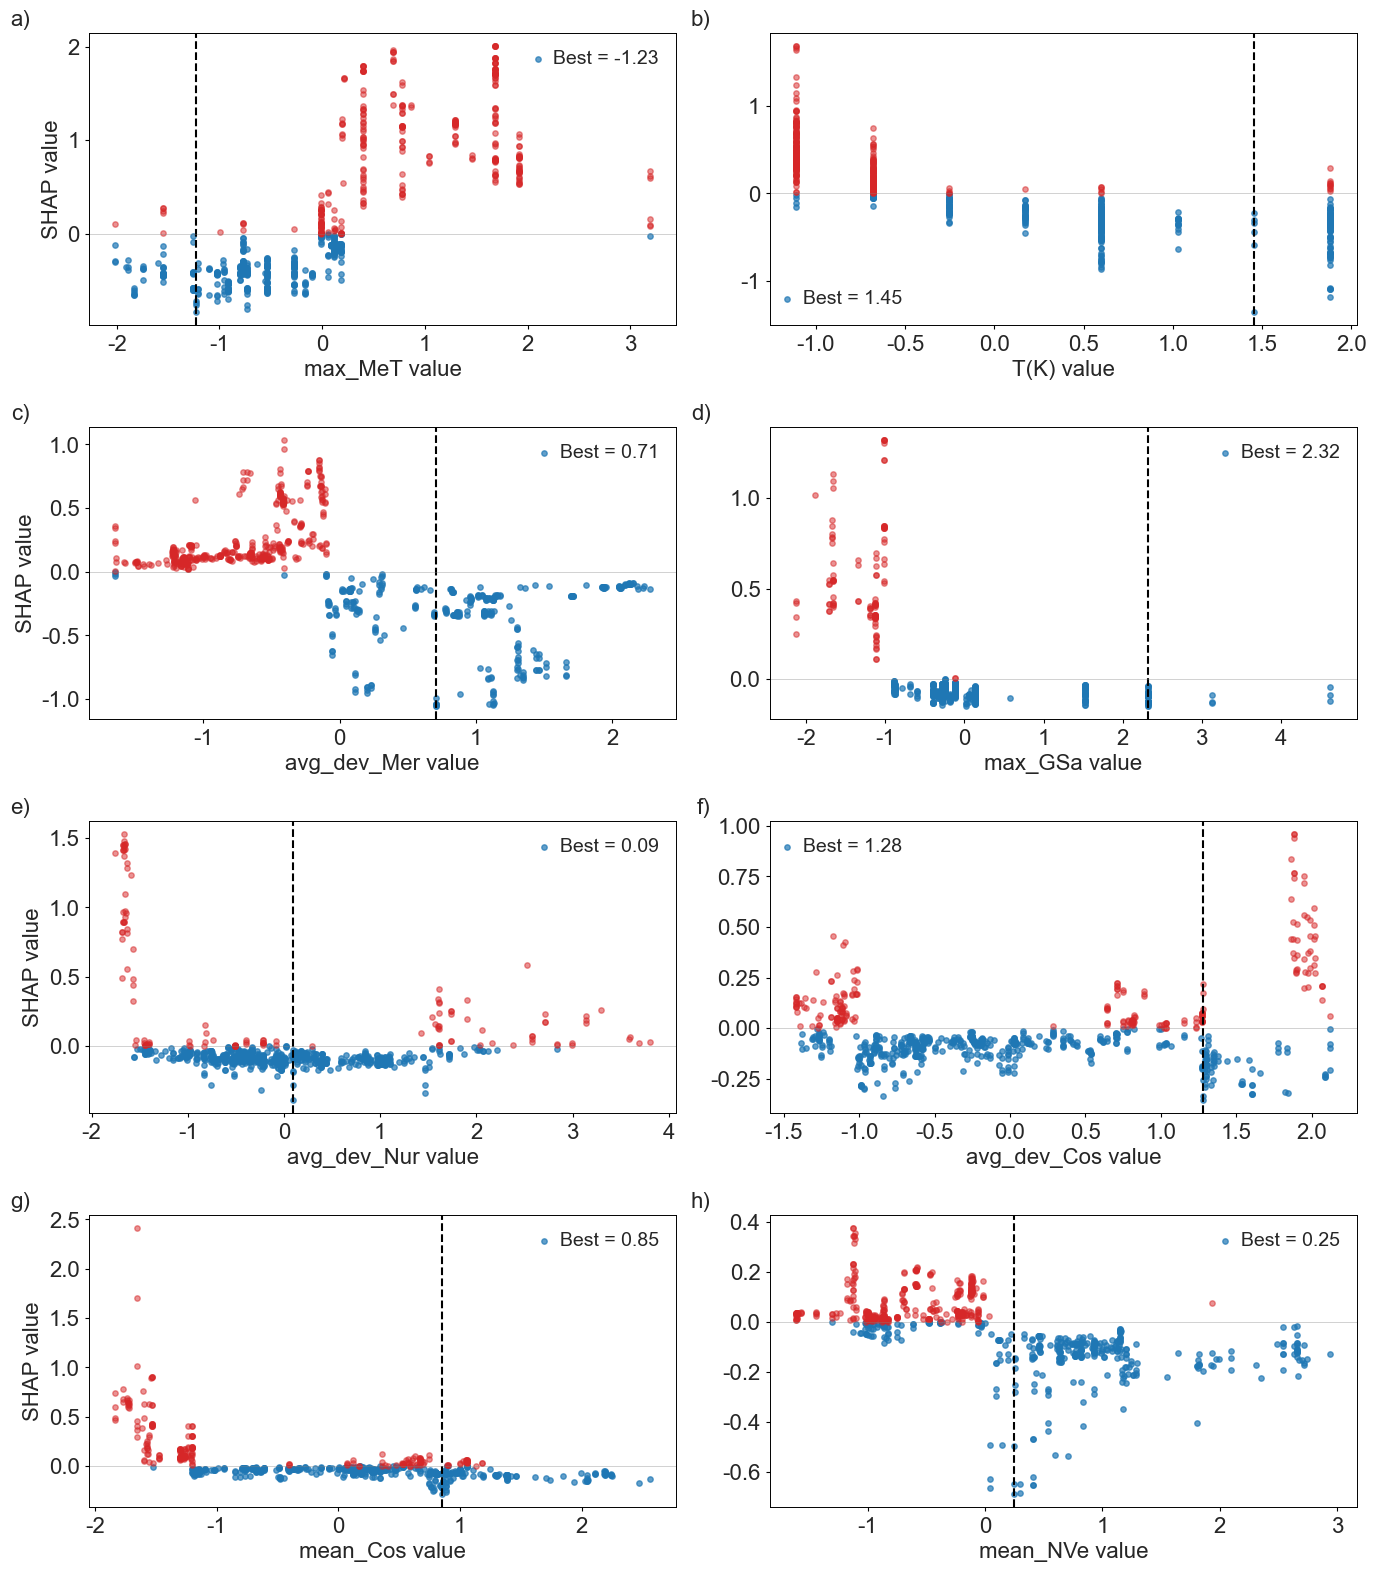

In [65]:
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
})


fig, ax = plt.subplots(4, 2, figsize=(14, 16))
axes = ax.ravel()

for i, fn in enumerate(top8_features):
    ax_i = axes[i]


    neg_mask = shap8_df[fn] < 0


    ax_i.scatter(X8_df[fn][neg_mask], shap8_df[fn][neg_mask],
                 c='#1f77b4', s=15, alpha=0.7, label='SHAP < 0 (Favorable)')
    ax_i.scatter(X8_df[fn][~neg_mask], shap8_df[fn][~neg_mask],
                 c='#d62728', s=15, alpha=0.5, label='SHAP >= 0')


    interval = results[fn]['interval']
    best_val = results[fn]['best_val']

    if interval is not None:

        ax_i.axvline(best_val, color='black', ls='--', linewidth=1.5, label=f'Best = {best_val:.2f}')


    ax_i.set_xlabel(f'{fn} value')

    if i % 2 == 0:
        ax_i.set_ylabel('SHAP value')


    ax_i.tick_params(direction='out', length=4, width=1.0, color='black', top=False, right=False)
    for spine in ax_i.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.7)

    # 刻度设置
    ax_i.tick_params(
        axis='both',
        which='major',
        direction='out',
        length=3,
        width=0.8,
        color='black',
        bottom=True,
        left=True,
        top=False,
        right=False
    )


    ax_i.axhline(0, color='gray', ls='-', linewidth=0.5, alpha=0.5)
    ax_i.grid(False)


    ax_i.legend(['Best = {:.2f}'.format(best_val)], loc='best', handlelength=0, frameon=False)


    ax_i.text(-0.1, 1.01, f'{chr(97+i)})', transform=ax_i.transAxes,
              fontsize=16, va='bottom', ha='right')

plt.tight_layout()
plt.show()

In [66]:
for fn in top8_features:
    v = results[fn]
    if v['interval'] is None:
        print(f"{fn:15s} : No negative interval detected")
    else:
        left, right = v['interval'].left, v['interval'].right
        best_val = v['best_val']
        zone_width = right - left

        # Add statistics, using X8_df instead of old X10_df
        zone_samples = X8_df[(X8_df[fn] >= left) & (X8_df[fn] <= right)]
        if len(zone_samples) > 0:
            coverage = len(zone_samples) / len(X8_df) * 100
            print(f"{fn:15s} : Recommended interval [{left:7.3f}, {right:7.3f}] (width: {zone_width:.3f})")
            print(f"{' ':15s}   → Optimal value (Best) = {best_val:7.3f} | Data coverage: {coverage:.1f}%")
        else:
            print(f"{fn:15s} : Recommended interval [{left:7.3f}, {right:7.3f}]")
            print(f"{' ':15s}   → Optimal value (Best) = {best_val:7.3f}")
print('=' * 75)

max_MeT         : Recommended interval [ -2.011,   0.188] (width: 2.199)
                  → Optimal value (Best) =  -1.226 | Data coverage: 69.8%
T(K)            : Recommended interval [ -0.254,   1.882] (width: 2.137)
                  → Optimal value (Best) =   1.455 | Data coverage: 51.7%
avg_dev_Mer     : Recommended interval [ -0.088,   2.276] (width: 2.364)
                  → Optimal value (Best) =   0.709 | Data coverage: 43.3%
max_GSa         : Recommended interval [ -0.888,   4.628] (width: 5.516)
                  → Optimal value (Best) =   2.323 | Data coverage: 86.3%
avg_dev_Nur     : Recommended interval [ -1.560,   1.716] (width: 3.276)
                  → Optimal value (Best) =   0.091 | Data coverage: 89.7%
avg_dev_Cos     : Recommended interval [ -1.388,   2.121] (width: 3.510)
                  → Optimal value (Best) =   1.281 | Data coverage: 98.2%
mean_Cos        : Recommended interval [ -1.200,   2.188] (width: 3.388)
                  → Optimal value (Best) =   


Plotting Figure 7: Summary of optimal feature intervals...


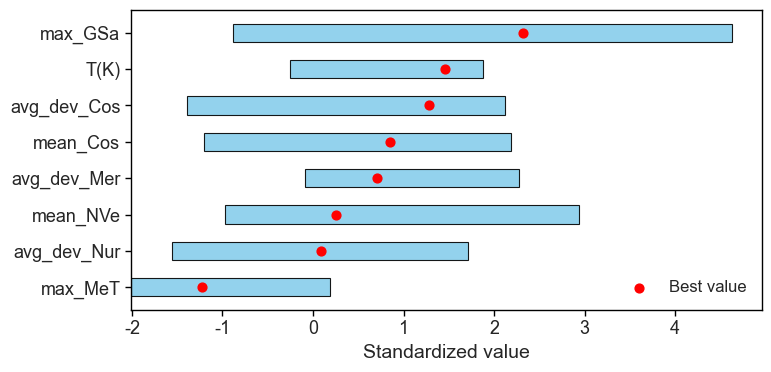

In [67]:

print("\nPlotting Figure 7: Summary of optimal feature intervals...")

# ---------- Extract data for plotting ----------
plot_data = []
# Note: Using top8_features defined in the previous step, not the old feature_names
for fn in top8_features:
    v = results[fn]
    if v['interval'] is not None:
        plot_data.append({
            'feat': fn,
            'left': v['interval'].left,
            'right': v['interval'].right,
            'best': v['best_val']
        })

# Create DataFrame
plot_df = pd.DataFrame(plot_data)
# Sort by best value to create a stepped pattern and visually cleaner layout
plot_df = plot_df.sort_values('best', ascending=True).reset_index(drop=True)

# ---------- Start plotting ----------
fig7, ax7 = plt.subplots(figsize=(8, max(4, 0.4 * len(plot_df))))

# Set white background
fig7.patch.set_facecolor('white')
ax7.set_facecolor('white')

y_pos = np.arange(len(plot_df))

# Draw horizontal interval bars - using light blue (Optimal Range)
for i, row in plot_df.iterrows():
    ax7.barh(y_pos[i], width=row.right - row.left,
             left=row.left, height=0.5,
             color='skyblue', edgecolor='k', linewidth=0.8, alpha=0.9)

# Optimal values (red scatter points)
ax7.scatter(plot_df.best, y_pos, color='red', s=40, zorder=3, label='Best value')

# Axis decorations
ax7.set_yticks(y_pos)
ax7.set_yticklabels(plot_df.feat, fontsize=13)
ax7.set_xlabel('Standardized value', fontsize=14)

# Avoid legend duplication (scatter automatically merges into a single legend)
ax7.legend(loc='best', frameon=False, fontsize=12)

# No grid lines
ax7.grid(False)

# Set all four borders to black
for spine in ax7.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Set tick parameters
ax7.tick_params(
    axis='both',
    which='major',
    direction='out',
    length=4,
    width=1.0,
    color='black',
    bottom=True,
    left=True,
    top=False,             # Ensure no ticks on top
    right=False,           # Ensure no ticks on right
    labelsize=13
)

plt.tight_layout()
plt.show()

### Prediction Phase

In [68]:

joblib.dump(xgb_model, 'model/xgb_k_model.pkl')


joblib.dump(scaler, 'model/scaler.pkl')

joblib.dump(X_train.columns.tolist(), 'model/feature_order.pkl')

['model/feature_order.pkl']

In [69]:
# 1. Load three essential components
model = joblib.load('model/xgb_k_model.pkl')
scaler = joblib.load('model/scaler.pkl')
feat_order = joblib.load('model/feature_order.pkl')  # Column order during training

In [70]:
# 2. Read new data (without k)
new_df = pd.read_csv('csv/new_magpie.csv')

# 3. Align columns & missing values
X_new = new_df[feat_order]          # Slice according to training order
X_new = X_new.fillna(X_new.mean())  # Consistent with training

# 4. Standardize
X_new_scaled = scaler.transform(X_new)

# 5. Predict
kl_pred = model.predict(X_new_scaled)

In [71]:
def short_name(s):
    """Function you provided, no changes needed"""
    s = re.sub(r'^MagpieData\s+', '', s)
    parts = s.split()
    if len(parts) >= 2:
        stat_type, prop_name = parts[0], ' '.join(parts[1:])
        stat_abbr = {'maximum':'max', 'minimum':'min',
                     'avg_dev':'avg_dev', 'mean':'mean'}.get(stat_type, stat_type)
        clean_prop = prop_name.replace(' ', '').replace('_', '')
        prop_abbr = clean_prop[:2] + clean_prop[-1] if len(clean_prop) >= 3 else clean_prop
        return f"{stat_abbr}_{prop_abbr}"
    return (s[:10] + '…') if len(s) > 10 else s

# 1. Extract original long names
long_names = scaler.get_feature_names_out()   # or scaler.feature_names_in_

# 2. Generate short names
short_names = [short_name(n) for n in long_names]

# 3. Assemble into DataFrame, column names are simplified feature names
X_new_df = pd.DataFrame(X_new_scaled, columns=short_names)

# # 4. View results
# print(X_new_df.head())

In [72]:
# ---------- 1. Create long name to short name mapping ----------
name_map = {ln: sn for ln, sn in zip(long_names, short_names)}

# ---------- 2. Given 10 "symmetric" intervals ----------
intervals = {
    'max_MeT': [-1.226, -0.730],
    'T(K)': [1.455, 1.882],
    'avg_dev_Mer': [0.709, 1.129],
    'max_GSa': [-0.279, 2.323],
    'avg_dev_Nur': [-0.757, 1.470],
    'avg_dev_Cos': [-0.841, 1.607],
    'mean_Cos': [0.776, 0.880],
    'mean_NVe': [0.040, 0.406]
}

# ---------- 3. Statistics + Print ----------
df = pd.DataFrame(X_new_scaled, columns=short_names)

for short, (lo, hi) in intervals.items():
    # Find corresponding column
    if short not in df.columns:
        print(f'{short:20s}: Not found in current features')
        continue
    col = df[short]
    n_inside = col.between(lo, hi).sum()
    print(f'{short:20s}: [{lo:7.3f}, {hi:7.3f}] → {n_inside}')

max_MeT             : [ -1.226,  -0.730] → 19
T(K)                : [  1.455,   1.882] → 2
avg_dev_Mer         : [  0.709,   1.129] → 15
max_GSa             : [ -0.279,   2.323] → 73
avg_dev_Nur         : [ -0.757,   1.470] → 93
avg_dev_Cos         : [ -0.841,   1.607] → 55
mean_Cos            : [  0.776,   0.880] → 10
mean_NVe            : [  0.040,   0.406] → 2


In [73]:
# ---------- 1. Create long name to short name mapping ----------
name_map = {ln: sn for ln, sn in zip(long_names, short_names)}

# ---------- 2. Given 10 "symmetric" intervals ----------
intervals = {
    'max_MeT': [-1.226, -0.730],
    'T(K)': [1.455, 1.882],
    'avg_dev_Mer': [0.709, 1.129],
    'max_GSa': [-0.279, 2.323],
    'avg_dev_Nur': [-0.757, 1.470],
    'avg_dev_Cos': [-0.841, 1.607],
    'mean_Cos': [0.776, 0.880],
    'mean_NVe': [0.040, 0.406]
}

# ---------- 3. Statistics + Print ----------
df = pd.DataFrame(X_new_scaled, columns=short_names)

# Store sample IDs for each interval
interval_samples = {}

for short, (lo, hi) in intervals.items():
    # Find corresponding column
    if short not in df.columns:
        print(f'{short:20s}: Not found in current features')
        continue

    col = df[short]
    # Find sample indices within interval
    mask = col.between(lo, hi)
    n_inside = mask.sum()

    # Get sample IDs
    sample_ids = df[mask].index.tolist()

    # Store results
    interval_samples[short] = sample_ids

    # Print results
    print(f'{short:20s}: [{lo:7.3f}, {hi:7.3f}] → {n_inside} samples')

    # If sample count is small, display specific sample IDs
    if n_inside <= 10:
        if n_inside > 0:
            print(f'     Sample IDs: {sample_ids}')
    else:
        # If too many samples, only show first 10
        print(f'     First 10 sample IDs: {sample_ids[:10]}...')
        print(f'     (Total {n_inside} samples)')
    print('-' * 50)

# ---------- 4. Check which intervals each sample hits ----------
print('\n' + '='*80)
print('Interval hit statistics for each sample:')
print('='*80)

# Create a dictionary to store intervals hit by each sample
sample_hits = {}

# Iterate through each interval, add samples to corresponding sets
for short, sample_list in interval_samples.items():
    for sample_id in sample_list:
        if sample_id not in sample_hits:
            sample_hits[sample_id] = []
        sample_hits[sample_id].append(short)

# Count distribution of hit counts
hit_count_dist = {}
for sample_id, intervals_list in sample_hits.items():
    hit_count = len(intervals_list)
    if hit_count not in hit_count_dist:
        hit_count_dist[hit_count] = []
    hit_count_dist[hit_count].append(sample_id)

# Print hit distribution
print(f'\nHit count distribution:')
for count in sorted(hit_count_dist.keys()):
    samples = hit_count_dist[count]
    print(f'  Hit {count} intervals: {len(samples)} samples')

# Print samples with most interval hits
print(f'\nSamples with most interval hits (top 20):')
sorted_samples = sorted(sample_hits.items(), key=lambda x: len(x[1]), reverse=True)

for i, (sample_id, intervals_list) in enumerate(sorted_samples[:50]):
    print(f'  Sample {sample_id:4d}: hit {len(intervals_list):2d} intervals → {intervals_list}')

# ---------- 5. Create result DataFrame ----------
# Create DataFrame containing hit information for each sample
hit_data = []
for sample_id in range(len(df)):
    if sample_id in sample_hits:
        hit_features = sample_hits[sample_id]
    else:
        hit_features = []

    hit_data.append({
        'sample_id': sample_id,
        'n_intervals_hit': len(hit_features),
        'hit_features': hit_features
    })

hit_df = pd.DataFrame(hit_data)
print(f'\nHit status for first 50 samples:')
print(hit_df.head(50))

max_MeT             : [ -1.226,  -0.730] → 19 samples
     First 10 sample IDs: [9, 10, 11, 13, 26, 35, 36, 38, 39, 40]...
     (Total 19 samples)
--------------------------------------------------
T(K)                : [  1.455,   1.882] → 2 samples
     Sample IDs: [70, 78]
--------------------------------------------------
avg_dev_Mer         : [  0.709,   1.129] → 15 samples
     First 10 sample IDs: [26, 35, 36, 38, 39, 40, 41, 42, 43, 44]...
     (Total 15 samples)
--------------------------------------------------
max_GSa             : [ -0.279,   2.323] → 73 samples
     First 10 sample IDs: [7, 20, 21, 22, 23, 24, 25, 27, 28, 29]...
     (Total 73 samples)
--------------------------------------------------
avg_dev_Nur         : [ -0.757,   1.470] → 93 samples
     First 10 sample IDs: [7, 8, 9, 10, 11, 12, 13, 14, 15, 20]...
     (Total 93 samples)
--------------------------------------------------
avg_dev_Cos         : [ -0.841,   1.607] → 55 samples
     First 10 sample IDs:

In [74]:
# ---------- 1. Construct (n_sample, 10) boolean matrix ----------
# First extract lower and upper bounds in intervals order
intv_order = list(intervals.keys())          # Fixed order
lows  = np.array([intervals[k][0] for k in intv_order])
highs = np.array([intervals[k][1] for k in intv_order])

# Corresponding column positions in DataFrame
idx_map = {fn: short_names.index(fn) for fn in intv_order}

# Extract these 10 column feature values
X10 = X_new_scaled[:, [idx_map[fn] for fn in intv_order]]  # shape (n_samples, 10)

# Single broadcast comparison
hit_mat = (X10 >= lows) & (X10 <= highs)   # Boolean matrix, True=fall into corresponding interval

# ---------- 2. How many intervals each sample hits ----------
hits_per_sample = hit_mat.sum(axis=1)      # shape (n_samples,)

# ---------- 3. Get specific feature names hit by each sample ----------
hit_features_per_sample = []

for i in range(len(hits_per_sample)):
    # Find feature indices hit by this sample
    hit_indices = np.where(hit_mat[i])[0]
    # Convert indices to feature names
    hit_features = [intv_order[idx] for idx in hit_indices]
    hit_features_per_sample.append(hit_features)

# ---------- 4. Create result DataFrame ----------
hit_df = pd.DataFrame({
    'sample_id': np.arange(len(hits_per_sample)),
    'n_intervals_hit': hits_per_sample,
    'hit_features': hit_features_per_sample
})

print("Hit status for first 50 samples:")
print(hit_df.head(50))

Hit status for first 50 samples:
    sample_id  n_intervals_hit  \
0           0                0   
1           1                0   
2           2                0   
3           3                1   
4           4                1   
5           5                1   
6           6                1   
7           7                3   
8           8                1   
9           9                3   
10         10                3   
11         11                3   
12         12                2   
13         13                3   
14         14                2   
15         15                2   
16         16                1   
17         17                2   
18         18                2   
19         19                1   
20         20                2   
21         21                2   
22         22                2   
23         23                2   
24         24                2   
25         25                2   
26         26                4   
27         27  

In [75]:
# 6. Save results
new_df['pred_k(W/mK)'] = kl_pred
new_df.to_csv('csv/xgb_new.csv', index=False)

### New Data

In [76]:
# Read data
data = pd.read_csv('csv/new_k.csv')

# Extract true and predicted values
true_vals = data['true_k(W/mK)'].values
pred_vals = data['pred_k(W/mK)'].values


r2 = r2_score(true_vals, pred_vals)
rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))

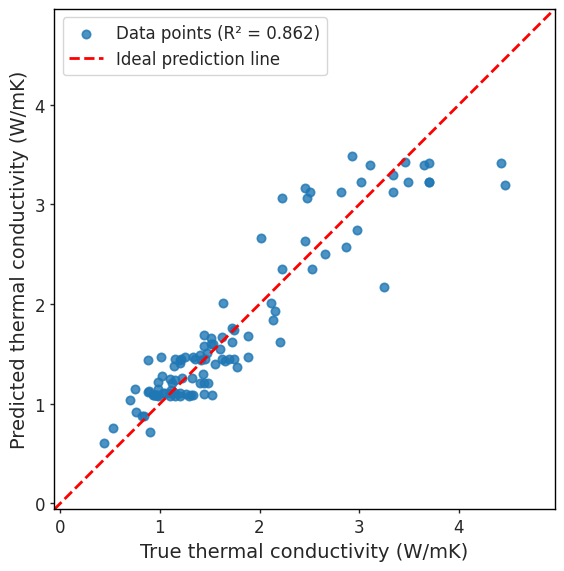

Coefficient of determination R² = 0.862
Root Mean Square Error RMSE = 0.328 W/mK


In [77]:
# Configure matplotlib settings
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot scatter plot
ax.scatter(true_vals, pred_vals,
           facecolors='tab:blue',   # Key for hollow
           edgecolors='tab:blue',
           linewidth=1.2,
           alpha=0.8,
           label=f'Data points (R² = {r2:.3f})')

# Plot diagonal line y=x
lim = [min(true_vals.min(), pred_vals.min()) - 0.5, max(true_vals.max(), pred_vals.max()) + 0.5]
ax.plot(lim, lim, 'r--', lw=2, label='Ideal prediction line')

# Add labels and title
ax.set_xlabel('True thermal conductivity (W/mK)', fontsize=14)
ax.set_ylabel('Predicted thermal conductivity (W/mK)', fontsize=14)
#ax.set_title('Predicted vs True Thermal Conductivity', fontsize=14, fontweight='bold')

# Add legend
ax.legend(fontsize=12)

# Set equal aspect ratio axes
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal', adjustable='box')

# Set tick marks
ax.tick_params(which='both',
               direction='out',
               top=False,      # Turn off top
               right=False,    # Turn off right
               left=True,      # Turn on left
               bottom=True,    # Turn on bottom
               length=3,
               width=1,
               labelsize=12)

# Adjust layout
plt.tight_layout()

# Display figure
plt.show()
print(f'Coefficient of determination R² = {r2:.3f}')
print(f'Root Mean Square Error RMSE = {rmse:.3f} W/mK')